In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

# Exercise 1

In [2]:
# a
x,y,z = sp.symbols('x y z')

eq1 = sp.Eq(x + 2*y + z, 0)
eq2 = sp.Eq(2*x - y + z, 0)
eq3 = sp.Eq(2*x + y, 0)

solution = sp.solve([eq1, eq2, eq3], [x,y,z])
print(solution)

{x: 0, y: 0, z: 0}


In [3]:
x,y,z,t = sp.symbols('x y z t')

eq1 = sp.Eq(2*x + y + z + t, 1)
eq2 = sp.Eq(x + 2*y + z + t, 1)
eq3 = sp.Eq(x + y + 2*z + 2*t, 1)
eq4 = sp.Eq(x + y + z + 2*t, 1)

solution = sp.solve([eq1, eq2, eq3,eq4], [x,y,z,t])
print(solution)

{t: 1/4, x: 1/4, y: 1/4, z: 0}


# Exercise 2

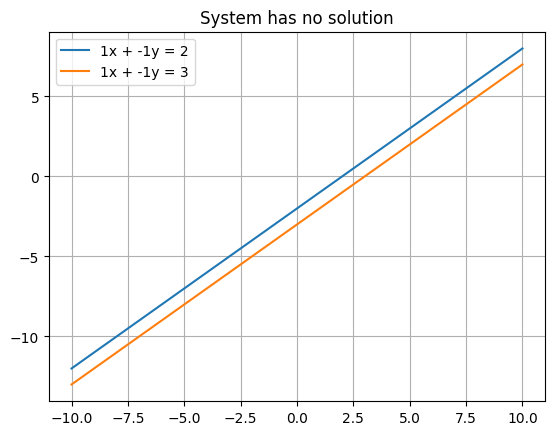

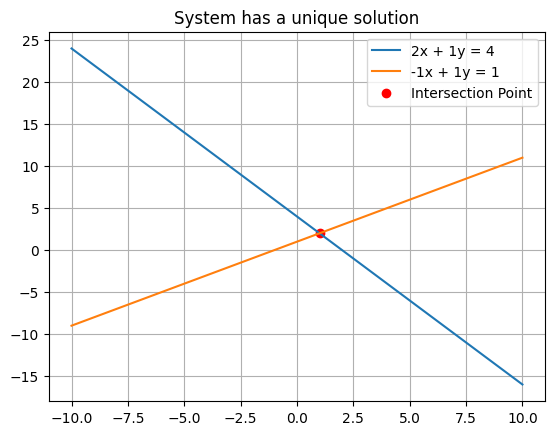

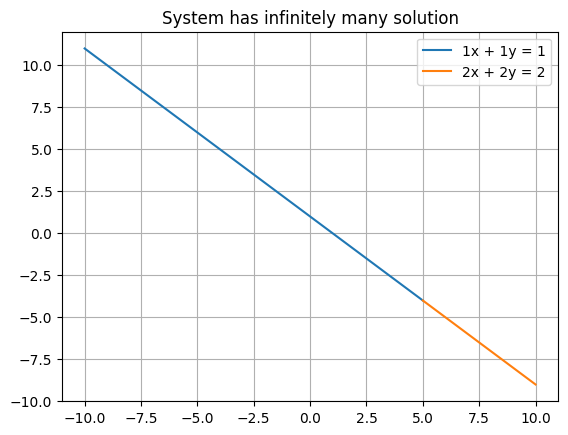

In [4]:
def draw2D(a1,b1,c1,a2,b2,c2,solution=None, many_solution=False):
  if many_solution == False:
    x = np.linspace(-10, 10, 400)
    y1 = (c1 - a1 * x) / b1
    y2 = (c2 - a2 * x) / b2
    plt.plot(x, y1, label=f"{a1}x + {b1}y = {c1}")
    plt.plot(x, y2, label=f"{a2}x + {b2}y = {c2}")

    if solution is not None:
      plt.scatter(*solution, color='red', label="Intersection Point")
      plt.title("System has a unique solution")
    else:
      plt.title("System has no solution")

  else:
    x1 = np.linspace(-10, 5, 400)
    x2 = np.linspace(5, 10, 400)
    y1 = (c1 - a1 * x1) / b1
    y2 = (c2 - a2 * x2) / b2
    plt.plot(x1, y1, label=f"{a1}x + {b1}y = {c1}")
    plt.plot(x2, y2, label=f"{a2}x + {b2}y = {c2}")
    plt.title("System has infinitely many solution")

  plt.legend()
  plt.grid()
  plt.show()


def analyze_system(a1,b1,c1,a2,b2,c2):
  A = np.array([[a1,b1],
                [a2,b2]])
  b = np.array([[c1],[c2]])

  A_extended = np.hstack((A,b))

  rank_A = np.linalg.matrix_rank(A)
  rank_A_extended = np.linalg.matrix_rank(A_extended)

  if rank_A != rank_A_extended:
    draw2D(a1,b1,c1,a2,b2,c2)

  elif rank_A == rank_A_extended == A.shape[1]:
    solution = tuple(np.linalg.solve(A, b).ravel())
    draw2D(a1,b1,c1,a2,b2,c2,solution=solution)

  else:
    many_solution = True
    draw2D(a1,b1,c1,a2,b2,c2,many_solution=many_solution)


analyze_system(1, -1, 2, 1, -1, 3)
analyze_system(2, 1, 4, -1, 1, 1)
analyze_system(1, 1, 1, 2, 2, 2)

# Exercise 3

(200, 200)


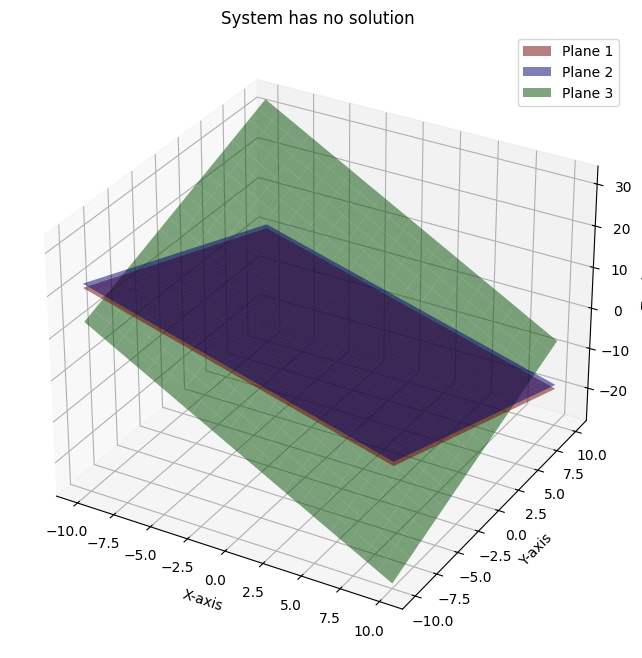

(200, 200)


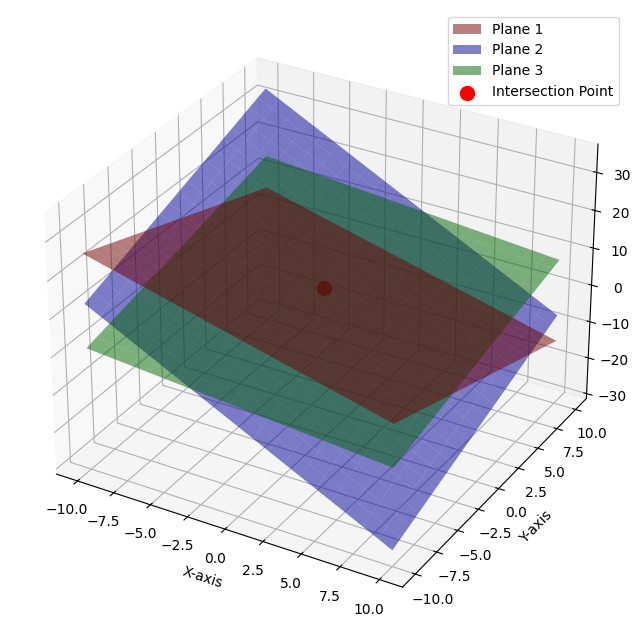

(200, 200)


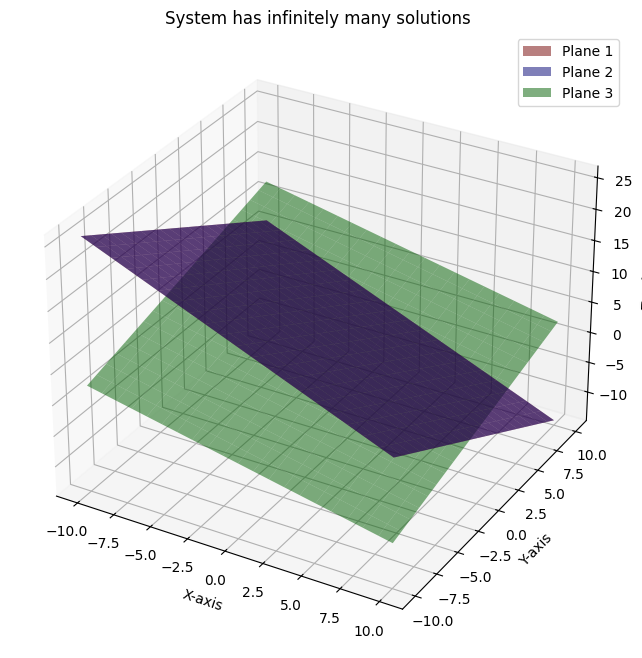

In [11]:
def draw3D(coefficient_1, coefficient_2, coefficient_3, solution=None,\
           many_solution=False):
  a1,b1,c1,d1 = coefficient_1
  a2,b2,c2,d2 = coefficient_2
  a3,b3,c3,d3 = coefficient_3

  x = np.linspace(-10, 10, 200)
  y = np.linspace(-10, 10, 200)
  X, Y = np.meshgrid(x,y)

  Z1 = np.where(c1 != 0, (d1 - a1 * X - b1 * Y) / c1, np.nan)
  Z2 = np.where(c2 != 0, (d2 - a2 * X - b2 * Y) / c2, np.nan)
  Z3 = np.where(c3 != 0, (d3 - a3 * X - b3 * Y) / c3, np.nan)

  fig = plt.figure(figsize=(10,8))
  ax = plt.axes(projection='3d')

  ax.plot_surface(X, Y, Z1, alpha=0.5, rstride=10, cstride=10, color='red', label='Plane 1')
  ax.plot_surface(X, Y, Z2, alpha=0.5, rstride=10, cstride=10, color='blue', label='Plane 2')
  ax.plot_surface(X, Y, Z3, alpha=0.5, rstride=10, cstride=10, color='green', label='Plane 3')

  ax.set_xlabel('X-axis')
  ax.set_ylabel('Y-axis')
  ax.set_zlabel('Z-axis')

  if solution is not None:
    x_sol, y_sol, z_sol = solution
    is_on_plane1 = np.isclose(a1*x_sol + b1*y_sol + c1*z_sol, d1)
    is_on_plane2 = np.isclose(a2*x_sol + b2*y_sol + c2*z_sol, d2)
    is_on_plane3 = np.isclose(a3*x_sol + b3*y_sol + c3*z_sol, d3)

    if is_on_plane1 and is_on_plane2 and is_on_plane3:
        ax.scatter(*solution, color='red', s=100, label="Intersection Point")
    else:
        print("Calculated solution does not satisfy all equations.")

  elif many_solution:
     ax.set_title("System has infinitely many solutions")

  else:
    ax.set_title("System has no solution")

  plt.legend()
  plt.show()


def analyze_system(coefficient_1, coefficient_2, coefficient_3):
  a1,b1,c1,d1 = coefficient_1
  a2,b2,c2,d2 = coefficient_2
  a3,b3,c3,d3 = coefficient_3

  A = np.array([[a1,b1,c1],
                [a2,b2,c2],
                [a3,b3,c3]])
  b = np.array([[d1],[d2],[d3]])

  A_extended = np.hstack((A,b))

  rank_A = np.linalg.matrix_rank(A)
  rank_A_extended = np.linalg.matrix_rank(A_extended)

  if rank_A != rank_A_extended:
    draw3D(coefficient_1, coefficient_2, coefficient_3)

  elif rank_A == rank_A_extended == A.shape[1]:
    try:
        # Hệ phương trình có nghiệm duy nhất
        solution = tuple(np.linalg.solve(A, b).ravel())
        draw3D(coefficient_1, coefficient_2, coefficient_3, solution=solution)
    except np.linalg.LinAlgError:
        print("Matrix is singular, no unique solution.")

  else:
    draw3D(coefficient_1, coefficient_2, coefficient_3,many_solution=True)

# no solution
coefficient_1 = [1, 1, 1, 1]
coefficient_2 = [1, 1, 1, 2]
coefficient_3 = [2, -1, 1, 3]
analyze_system(coefficient_1, coefficient_2, coefficient_3)

# unique solution
coefficient_1 = [1, 1, 1, 6]
coefficient_2 = [2, -1, 1, 3]
coefficient_3 = [1, -2, 3, 14]
analyze_system(coefficient_1, coefficient_2, coefficient_3)

# many solution
coefficient_1 = [1, 1, 1, 6]
coefficient_2 = [2, 2, 2, 12]
coefficient_3 = [1, -1, 2, 5]
analyze_system(coefficient_1, coefficient_2, coefficient_3)


# Exercise 6

In [6]:
A = np.array([
    [1, 1, 1],
    [1, 2, 4],
    [1, 3, 9]
])

# Right-hand side
b = np.array([6, 15, 38])

# Solve for [a0, a1, a2]
coefficients = np.linalg.solve(A, b)
coefficients

array([ 11., -12.,   7.])

# Exercise 7

In [7]:
A = np.array([
    [3, 3.2],
    [3.5, 3.6]
])

# Right-hand side vector (total costs for bus and train trips)
b = np.array([118.4, 135.2])

# Solve the system of linear equations
solution = np.linalg.solve(A, b)

# Extract the number of children and adults
children, adults = solution

print(f"Number of children: {int(round(children))}")
print(f"Number of adults: {int(round(adults))}")

Number of children: 16
Number of adults: 22


# Exercise 10

In [8]:
A = np.array([
    [0.25, 0.15, 0.1],
    [0.4, 0.15, 0.2],
    [0.15, 0.2, 0.2]
])

# Demand vector d
d = np.array([100, 100, 100])

# Identity matrix I
I = np.eye(3)

# Compute (I - A)
I_minus_A = I - A

# Compute production vector p
p = np.linalg.inv(I_minus_A) @ d

print("Production vector p:")
print(p)

Production vector p:
[220.03687769 276.58266749 235.40258144]


# Exercise 11

In [9]:
import sympy as sp

# Define the symbols for x1, x2, x3, x4
x1, x2, x3, x4 = sp.symbols('x1 x2 x3 x4')

# Set up the equations based on atomic balance
equations = [
    sp.Eq(3 * x1, x3),        # Carbon balance: 3*x1 = x3
    sp.Eq(8 * x1, 2 * x4),    # Hydrogen balance: 8*x1 = 2*x4
    sp.Eq(2 * x2, 2 * x3 + x4) # Oxygen balance: 2*x2 = 2*x3 + x4
]

# Solve the system of equations
solution = sp.solve(equations, (x2, x3, x4))

x2_expr = solution[x2]
x3_expr = solution[x3]
x4_expr = solution[x4]

# Đặt x1 = 1 để tính giá trị của x2, x3, x4
x1_value = 1
x2_value = x2_expr.subs(x1, 1)
x3_value = x3_expr.subs(x1, 1)
x4_value = x4_expr.subs(x1, 1)

print(f"Balanced equation: {x1_value}C3H8 + {x2_value}O2 -> {x3_value}CO2 + {x4_value}H2O")

Balanced equation: 1C3H8 + 5O2 -> 3CO2 + 4H2O
